# SpaceNet data prep

Builds a curated local sample of real SpaceNet road+building scenes for two cities (Vegas: dense grid, Khartoum: informal settlements), used by `real_data_evaluation.ipynb` and `composite_vs_submetric_report.ipynb`.

No cloud compute or credentials needed -- `spacenet-dataset` is a public, unauthenticated S3 bucket; `datasets.spacenet` fetches individual per-tile files directly.

In [ ]:
import sys, os
from pathlib import Path
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from datasets.spacenet import build_spacenet_sample

# Resolve to an absolute path so the cache lands in the repo's data/ dir
# regardless of the kernel's working directory (nbconvert runs notebooks with
# CWD set to the notebook's own folder, not the repo root).
DATA_DIR = Path("..").resolve() / "data"
CITIES = ["Vegas", "Khartoum"]
N_TILES_PER_CITY = 8

## Tiling-alignment note

SN3 road tiles (1300x1300px) and SN2 building tiles (650x650px) use **different tiling grids** even for the same city, so `img{N}` does not refer to the same geographic tile between the two datasets. `build_spacenet_sample`:

1. Uses each road tile's own raster as the canonical pixel grid (roads define class 1).
2. Finds spatially-overlapping SN2 building tiles via a coarse-then-dense nearest-neighbor search over tile centroids (tile ids are assigned in roughly raster-scan order over the city, verified empirically), rather than downloading every building tile.
3. Rejects any road tile whose matched building geometries rasterize to zero pixels -- a lon/lat bounding-box "hit" can still be a false positive when two tiles merely touch at a shared edge.

Road width comes from each segment's own `lane_number` property (buffered in pixels via the tile's GSD), consistent with PLEM's `d = physical_metres / GSD_metres_per_pixel` convention.

In [ ]:
# This downloads + rasterizes real tiles over the network -- takes a few
# minutes per city the first time; cached .npz files under data/spacenet/<city>/
# are reused on subsequent runs (download_file skips files that already exist).
samples_by_city = {}
for city in CITIES:
    print(f"Building sample for {city}...")
    samples_by_city[city] = build_spacenet_sample(
        city, n_tiles=N_TILES_PER_CITY, seed=0, cache_dir=str(DATA_DIR / "spacenet"),
    )
    print(f"  {len(samples_by_city[city])} tiles cached")

In [3]:
# Summary: pixel counts per class, per tile
for city, samples in samples_by_city.items():
    print(f"\n=== {city} ===")
    for s in samples:
        label = s["label"]
        print(f"  img{s['tile_id']}: road={100*(label==1).mean():.1f}%  "
              f"building={100*(label==2).mean():.1f}%  bg={100*(label==0).mean():.1f}%")


=== Vegas ===
  img1308: road=6.0%  building=11.4%  bg=82.5%
  img805: road=9.0%  building=0.6%  bg=90.4%
  img1485: road=15.6%  building=9.9%  bg=74.5%
  img627: road=9.6%  building=6.6%  bg=83.8%
  img1529: road=3.3%  building=2.8%  bg=93.9%
  img55: road=9.4%  building=11.3%  bg=79.3%
  img117: road=11.4%  building=4.9%  bg=83.7%
  img997: road=10.7%  building=6.0%  bg=83.3%

=== Khartoum ===
  img333: road=0.7%  building=2.4%  bg=96.9%
  img371: road=0.1%  building=0.0%  bg=99.9%
  img264: road=16.4%  building=3.5%  bg=80.1%
  img374: road=12.4%  building=17.6%  bg=70.0%
  img230: road=4.2%  building=12.0%  bg=83.8%
  img311: road=12.4%  building=3.7%  bg=83.9%
  img118: road=8.4%  building=10.6%  bg=81.1%
  img439: road=6.5%  building=16.4%  bg=77.1%


## Visual sanity check

RGB image next to the rasterized road (red) / building (green) overlay, for one tile per city -- confirms roads follow real driving lanes and buildings align with real rooftops (not just correct pixel counts).

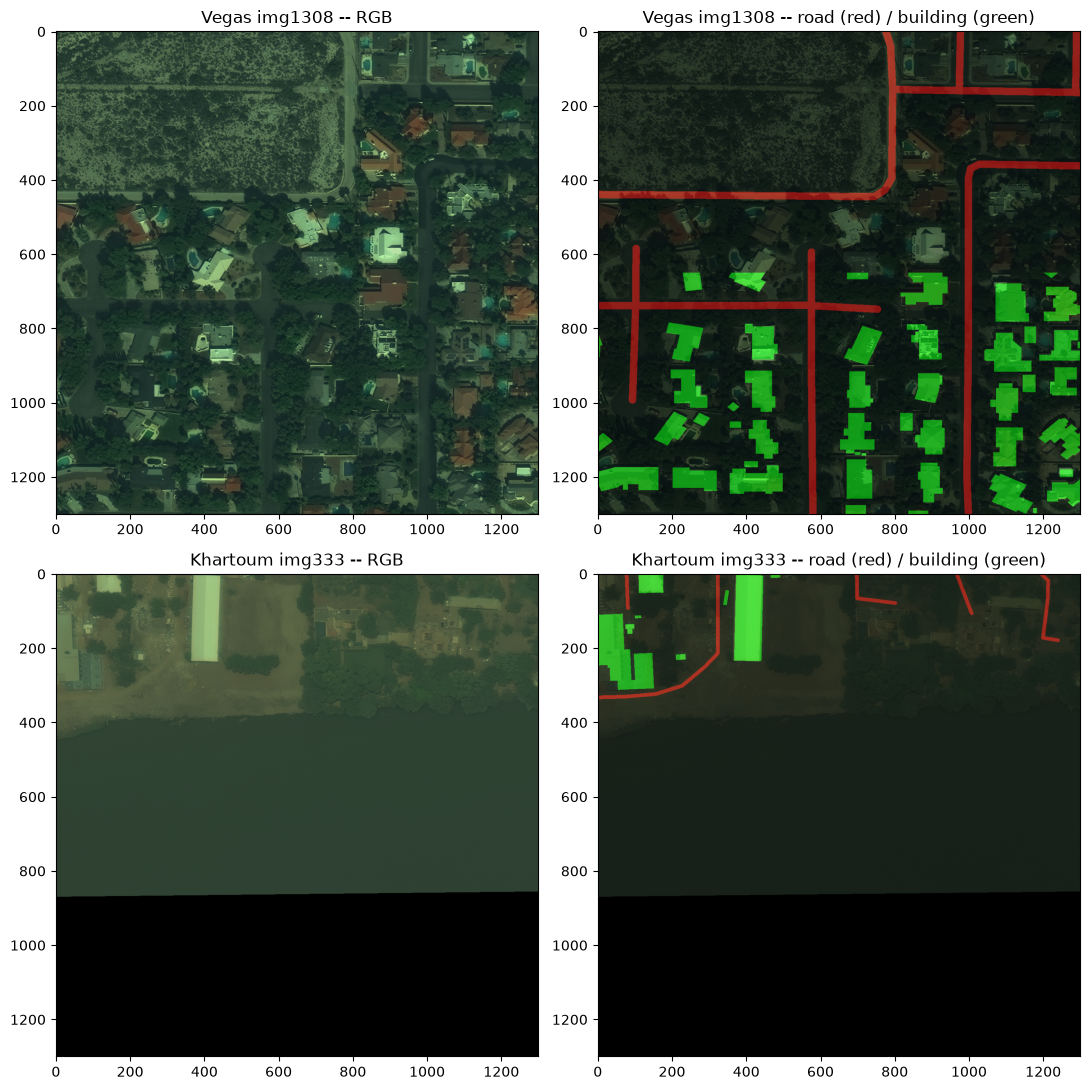

In [4]:
fig, axes = plt.subplots(len(CITIES), 2, figsize=(11, 5.5 * len(CITIES)))
if len(CITIES) == 1:
    axes = axes[None, :]

for row, city in enumerate(CITIES):
    s = samples_by_city[city][0]
    image, label = s["image"], s["label"]
    overlay = np.zeros((*label.shape, 3), dtype=np.uint8)
    overlay[label == 1] = [255, 0, 0]
    overlay[label == 2] = [0, 255, 0]

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f"{city} img{s['tile_id']} -- RGB")
    axes[row, 1].imshow(image)
    axes[row, 1].imshow(overlay, alpha=0.5)
    axes[row, 1].set_title(f"{city} img{s['tile_id']} -- road (red) / building (green)")

fig.tight_layout()
plt.show()